In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_csv("/content/IPL_Squad_2023_Auction_Dataset.csv")
data

,Unnamed: 0,Player's List,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2022 Squad,Team
0,0,Shivam Mavi,4000000,BOWLER,6.0,720.0,KKR,Gujarat Titans
1,1,Joshua Little,5000000,BOWLER,4.4,528.0,NaN,Gujarat Titans
2,2,Kane Williamson,20000000,BATSMAN,2.0,240.0,SRH,Gujarat Titans
3,3,K.S. Bharat,2000000,WICKETKEEPER,1.2,144.0,DC,Gujarat Titans
4,4,Mohit Sharma,5000000,BOWLER,0.5,60.0,NaN,Gujarat Titans
...,...,...,...,...,...,...,...,...
563,563,Dhruv Patel,2000000,ALL-ROUNDER,NaN,NaN,NaN,Unsold
564,564,Jack Prestwidge,2000000,ALL-ROUNDER,NaN,NaN,NaN,Unsold
565,565,Aditya Sarvate,2000000,ALL-ROUNDER,NaN,NaN,NaN,Unsold
566,566,Sagar Solanki,2000000,ALL-ROUNDER,NaN,NaN,NaN,Unsold


In [4]:
data.head()

,Unnamed: 0,Player's List,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2022 Squad,Team
0,0,Shivam Mavi,4000000,BOWLER,6.0,720.0,KKR,Gujarat Titans
1,1,Joshua Little,5000000,BOWLER,4.4,528.0,NaN,Gujarat Titans
2,2,Kane Williamson,20000000,BATSMAN,2.0,240.0,SRH,Gujarat Titans
3,3,K.S. Bharat,2000000,WICKETKEEPER,1.2,144.0,DC,Gujarat Titans
4,4,Mohit Sharma,5000000,BOWLER,0.5,60.0,NaN,Gujarat Titans


In [5]:
data.describe()

,Unnamed: 0,COST IN ₹ (CR.),Cost IN $ (000)
count,568.000000,243.000000,243.000000
mean,283.500000,0.687243,82.469136
std,164.111751,2.511700,301.404032
min,0.000000,0.000000,0.000000
25%,141.750000,0.000000,0.000000
50%,283.500000,0.000000,0.000000
75%,425.250000,0.200000,24.000000
max,567.000000,18.500000,2220.000000


In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
data.isna().sum()

,0
Unnamed: 0,0
Player's List,0
Base Price,0
TYPE,0
COST IN ₹ (CR.),325
Cost IN $ (000),325
2022 Squad,338
Team,0


In [8]:
num_cols = ['Base Price','COST IN ₹ (CR.)','Cost IN $ (000)']

for col in num_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568 entries, 0 to 567
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       568 non-null    int64  
 1   Player's List    568 non-null    object 
 2   Base Price       405 non-null    float64
 3   TYPE             568 non-null    object 
 4   COST IN ₹ (CR.)  243 non-null    float64
 5   Cost IN $ (000)  243 non-null    float64
 6   2022 Squad       230 non-null    object 
 7   Team             568 non-null    object 
dtypes: float64(3), int64(1), object(4)
memory usage: 35.6+ KB


In [10]:
data.loc[:, 'COST IN ₹ (CR.)'] = data['COST IN ₹ (CR.)'].fillna(0)
data.loc[:, 'Cost IN $ (000)'] = data['Cost IN $ (000)'].fillna(0)


In [11]:
data['2022 Squad'] = data['2022 Squad'].fillna('None')


In [12]:
data.isna().sum()

,0
Unnamed: 0,0
Player's List,0
Base Price,163
TYPE,0
COST IN ₹ (CR.),0
Cost IN $ (000),0
2022 Squad,0
Team,0


In [13]:
print(data.columns)


Index(['Unnamed: 0', 'Player's List', 'Base Price', 'TYPE', 'COST IN ₹ (CR.)',
       'Cost IN $ (000)', '2022 Squad', 'Team'],
      dtype='object')


In [14]:
data.drop(columns=['Unnamed: 0'] , inplace=True)

In [15]:
data

,Player's List,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2022 Squad,Team
0,Shivam Mavi,4000000.0,BOWLER,6.0,720.0,KKR,Gujarat Titans
1,Joshua Little,5000000.0,BOWLER,4.4,528.0,None,Gujarat Titans
2,Kane Williamson,20000000.0,BATSMAN,2.0,240.0,SRH,Gujarat Titans
3,K.S. Bharat,2000000.0,WICKETKEEPER,1.2,144.0,DC,Gujarat Titans
4,Mohit Sharma,5000000.0,BOWLER,0.5,60.0,None,Gujarat Titans
...,...,...,...,...,...,...,...
563,Dhruv Patel,2000000.0,ALL-ROUNDER,0.0,0.0,None,Unsold
564,Jack Prestwidge,2000000.0,ALL-ROUNDER,0.0,0.0,None,Unsold
565,Aditya Sarvate,2000000.0,ALL-ROUNDER,0.0,0.0,None,Unsold
566,Sagar Solanki,2000000.0,ALL-ROUNDER,0.0,0.0,None,Unsold


In [16]:
data["TYPE"].value_counts()

,count
TYPE,
ALL-ROUNDER,213
BOWLER,189
BATSMAN,91
WICKETKEEPER,75


<Axes: xlabel='count', ylabel='Team'>

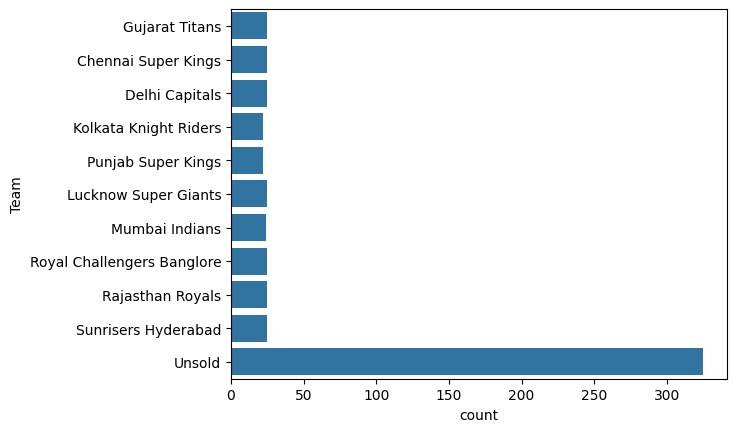

In [17]:
sns.countplot(data["Team"])

<Axes: xlabel='count', ylabel='TYPE'>

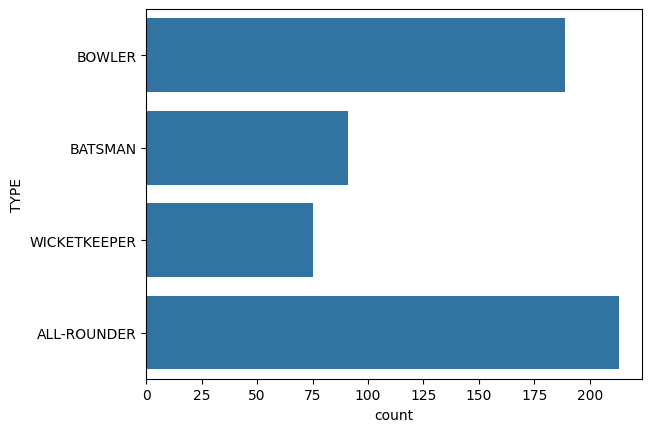

In [18]:
sns.countplot(data["TYPE"])

In [19]:
data["2022 Squad"].value_counts()

,count
2022 Squad,
None,338
MI,28
PBKS,24
RR,24
CSK,24
DC,23
KKR,22
SRH,22
GT,22


In [20]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
num_cols = ['Base Price','COST IN ₹ (CR.)','Cost IN $ (000)']

for col in num_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

data[num_cols] = data[num_cols].fillna(0)


scaler = MinMaxScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])


In [21]:
data

,Player's List,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2022 Squad,Team
0,Shivam Mavi,0.20,BOWLER,0.324324,0.324324,KKR,Gujarat Titans
1,Joshua Little,0.25,BOWLER,0.237838,0.237838,None,Gujarat Titans
2,Kane Williamson,1.00,BATSMAN,0.108108,0.108108,SRH,Gujarat Titans
3,K.S. Bharat,0.10,WICKETKEEPER,0.064865,0.064865,DC,Gujarat Titans
4,Mohit Sharma,0.25,BOWLER,0.027027,0.027027,None,Gujarat Titans
...,...,...,...,...,...,...,...
563,Dhruv Patel,0.10,ALL-ROUNDER,0.000000,0.000000,None,Unsold
564,Jack Prestwidge,0.10,ALL-ROUNDER,0.000000,0.000000,None,Unsold
565,Aditya Sarvate,0.10,ALL-ROUNDER,0.000000,0.000000,None,Unsold
566,Sagar Solanki,0.10,ALL-ROUNDER,0.000000,0.000000,None,Unsold


In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['TYPE'] = le.fit_transform(data['TYPE'])
data['2022 Squad'] = le.fit_transform(data['2022 Squad'])
data['Team'] = le.fit_transform(data['Team'])


In [23]:
data= data.drop('Player\'s List' , axis=1)

In [24]:
data.corr()

,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2022 Squad,Team
Base Price,1.000000,-0.005913,0.476795,0.476795,0.106796,0.173793
TYPE,-0.005913,1.000000,-0.019735,-0.019735,0.020523,0.020249
COST IN ₹ (CR.),0.476795,-0.019735,1.000000,1.000000,0.051383,-0.148304
Cost IN $ (000),0.476795,-0.019735,1.000000,1.000000,0.051383,-0.148304
2022 Squad,0.106796,0.020523,0.051383,0.051383,1.000000,0.574173
Team,0.173793,0.020249,-0.148304,-0.148304,0.574173,1.000000


In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568 entries, 0 to 567
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Base Price       568 non-null    float64
 1   TYPE             568 non-null    int64  
 2   COST IN ₹ (CR.)  568 non-null    float64
 3   Cost IN $ (000)  568 non-null    float64
 4   2022 Squad       568 non-null    int64  
 5   Team             568 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 26.8 KB


In [27]:
data['COST IN ₹ (CR.)'] = data['COST IN ₹ (CR.)'].round(3)
data['Cost IN $ (000)'] = data['Cost IN $ (000)'].round(3)

In [28]:
data

,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2022 Squad,Team
0,0.20,2,0.324,0.324,3,2
1,0.25,2,0.238,0.238,6,2
2,1.00,1,0.108,0.108,10,2
3,0.10,3,0.065,0.065,1,2
4,0.25,2,0.027,0.027,6,2
...,...,...,...,...,...,...
563,0.10,0,0.000,0.000,6,10
564,0.10,0,0.000,0.000,6,10
565,0.10,0,0.000,0.000,6,10
566,0.10,0,0.000,0.000,6,10
